Objective : Predict Electricity Demand Accurately To Optimize Power Generation And Distribution.

## Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import copy

from statsmodels.tsa.seasonal import seasonal_decompose as sd
from statsmodels.tsa.stattools import adfuller as adf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf as acf, plot_pacf as pacf

from pmdarima import auto_arima

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse

from itertools import product


## Data

In [2]:
# Import Data
data = pd.read_csv(r"D:\COURSE\DATA SCIENCE FULL COURSE BY UDEMY\SECTION 7 Time Series Analysis\Resources\drive-download-20260225T095330Z-1-001\Project 1 - ARIMA\TimeSeries_TotalSolarGen_and_Load_IT_2016.csv")
df = copy.deepcopy(data)

# Convert UTC Time Stamp in Data time Formate
df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'])

# Fill Null Values in Load Of Electricity
df['IT_load_new'] = df['IT_load_new'].fillna(df['IT_load_new'].median())

# Data Null Values
print('Data Null Values:\n\n', df.isna().sum())

# Data Describe
print('Data Describe :\n\n', df.describe())

df.head()

Data Null Values:

 utc_timestamp          0
IT_load_new            0
IT_solar_generation    0
dtype: int64
Data Describe :

         IT_load_new  IT_solar_generation
count   8784.000000          8784.000000
mean   32257.230988          2049.831853
std     7258.900376          2845.846870
min    16716.000000             0.000000
25%    25944.500000             0.000000
50%    31654.500000            68.000000
75%    38637.250000          3923.500000
max    48986.000000         15824.000000


,utc_timestamp,IT_load_new,IT_solar_generation
0,2016-01-01 00:00:00+00:00,21665.0,1
1,2016-01-01 01:00:00+00:00,20260.0,0
2,2016-01-01 02:00:00+00:00,19056.0,0
3,2016-01-01 03:00:00+00:00,18407.0,0
4,2016-01-01 04:00:00+00:00,18425.0,0


#### Self EDA

In [3]:
# 1. Italy Time Conversion
df['italy_time'] = df['utc_timestamp'].dt.tz_convert('Europe/Rome')

# 2. Data Where Solar Panel Generate Electricity At Night
filtered_data = df[(df['IT_solar_generation'] > 1) & ((df['italy_time'].dt.time >= pd.to_datetime('20:00:00').time()) | (df['italy_time'].dt.time <= pd.to_datetime('04:00:00').time()))]
print(len(filtered_data))

# 3. Hum maan kar chalte hain ki Italy mein raat 8 baje (20:00) se subah 5 baje (05:00) tak dhoop nahi hoti
# Hum data ko filter karenge sirf raat ke ghanton ke liye
night_data = df[(df['italy_time'].dt.hour >= 20) | (df['italy_time'].dt.hour <= 5)]

# 4. Ab check karte hain ki in raat ke ghanton mein kahan solar generation 0 se bada (>0) hai
error_data = night_data[night_data['IT_solar_generation'] > 0]

# 5. Result print karna
print("Total aisi rows jahan raat mein dhoop dikh rahi hai (Errors):", len(error_data))

# Aap un galat rows ko dekh bhi sakte hain
print(error_data.head())

# Jahan hour >=20 ya <=5 hai, wahan solar generation ko automatically 0 kar do
condition_night = (df['italy_time'].dt.hour >= 20) | (df['italy_time'].dt.hour <= 5)
df.loc[condition_night, 'IT_solar_generation'] = 0

878
Total aisi rows jahan raat mein dhoop dikh rahi hai (Errors): 1060
               utc_timestamp  IT_load_new  IT_solar_generation  \
0  2016-01-01 00:00:00+00:00      21665.0                    1   
20 2016-01-01 20:00:00+00:00      27681.0                    1   
21 2016-01-01 21:00:00+00:00      25626.0                    1   
22 2016-01-01 22:00:00+00:00      23131.0                    1   
43 2016-01-02 19:00:00+00:00      31760.0                   29   

                  italy_time  
0  2016-01-01 01:00:00+01:00  
20 2016-01-01 21:00:00+01:00  
21 2016-01-01 22:00:00+01:00  
22 2016-01-01 23:00:00+01:00  
43 2016-01-02 20:00:00+01:00  


### Visulization

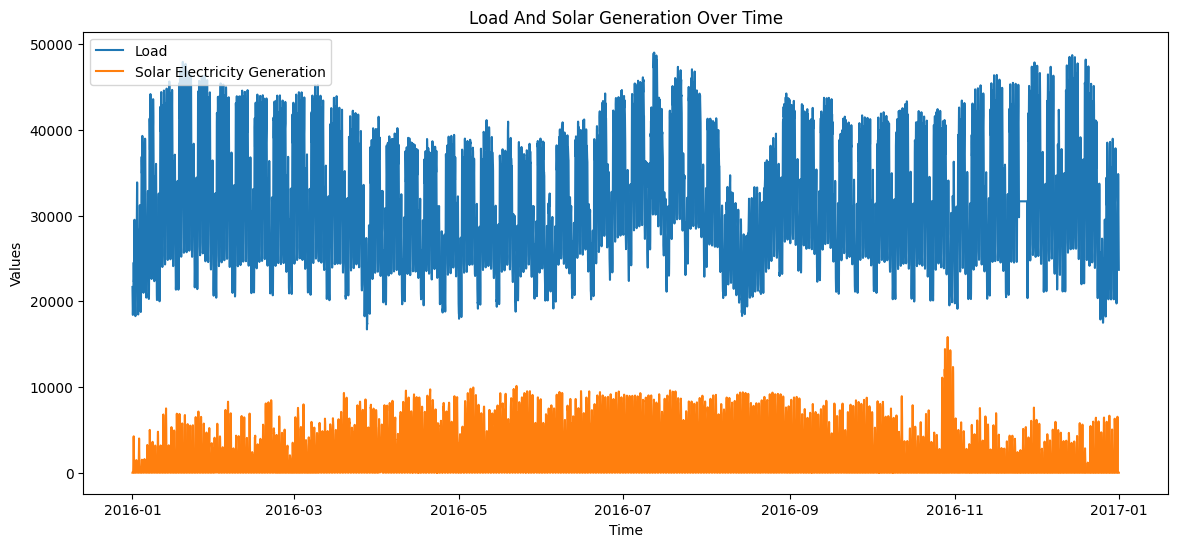

In [4]:
# Plot Load And Generation ALong With Timestamp
plt.figure(figsize=(14, 6))

plt.plot(df['utc_timestamp'], df['IT_load_new'], label='Load')
plt.plot(df['utc_timestamp'], df['IT_solar_generation'], label='Solar Electricity Generation')
plt.xlabel('Time')
plt.ylabel('Values')
plt.legend()
plt.title('Load And Solar Generation Over Time')
plt.show()

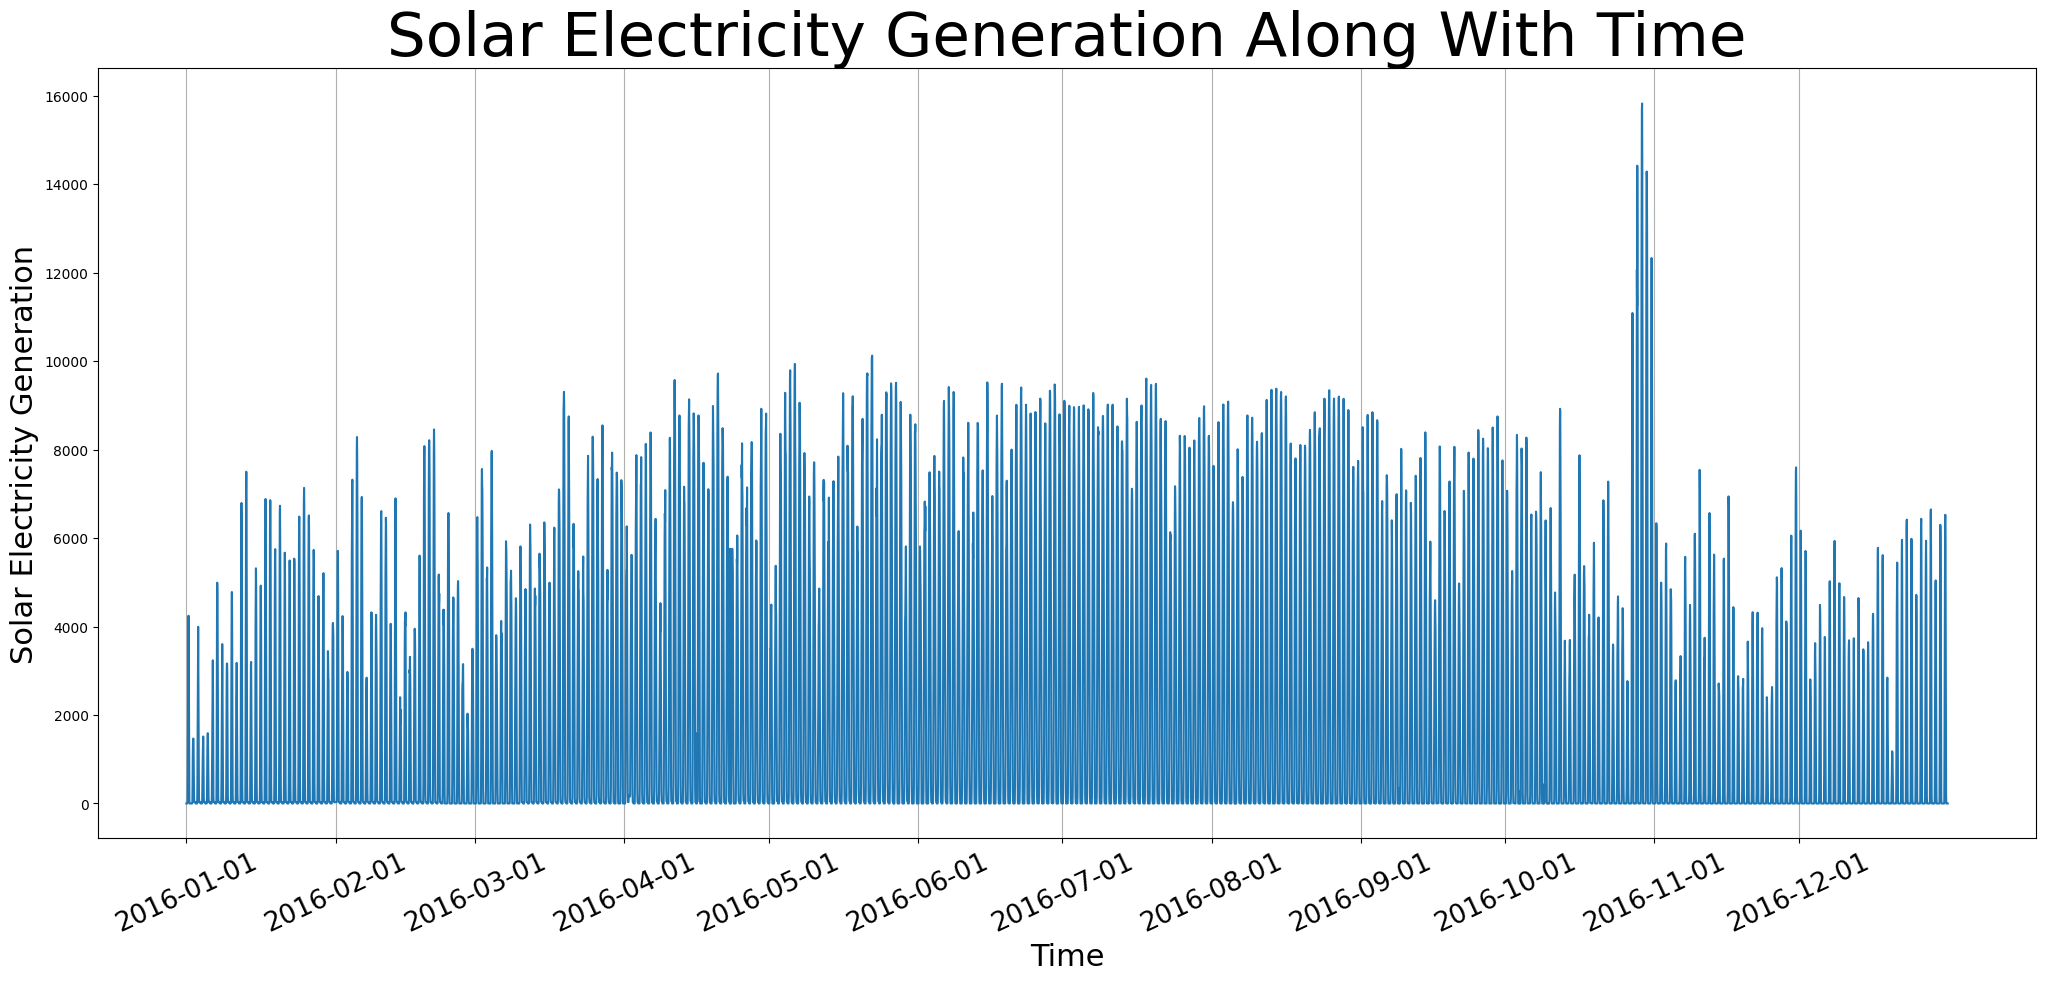

In [6]:
# Plot Only Solar Generation ALong With Timestamp
plt.figure(figsize=(25, 10))

plt.plot(df['utc_timestamp'], df['IT_solar_generation'], label='Solar Electricity Generation')
plt.xlabel('Time', fontsize=22)
plt.ylabel('Solar Electricity Generation', fontsize=22)
plt.title('Solar Electricity Generation Along With Time', fontsize=44)
plt.grid(axis='x')

# Create 12 monthly ticks
monthly_ticks = pd.date_range(
    start=df['utc_timestamp'].min(),
    end=df['utc_timestamp'].max(),
    freq='MS')   # Month Start

plt.xticks(monthly_ticks, rotation=25, fontsize=19)
plt.show()

### Seasonal Decomposition 

#### Electricity Seasonal Decomposition 

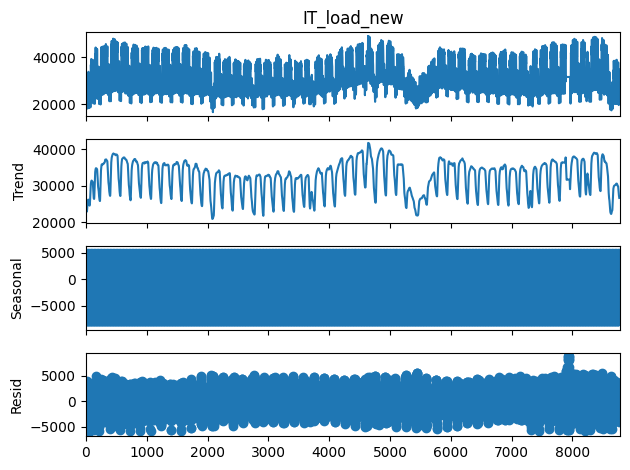

In [7]:
# For Electricity Load Data 
Raw_Load_Seasonal =  sd(df['IT_load_new'], model='Addictive', period=24) # Addictive Because Constant Trend Overall, Period = 24 Hours
Raw_Load_Seasonal.plot();

In [8]:
# Adf Test On Log Load Data
adf_log_load = adf(df['IT_load_new'], autolag='AIC')

Name = ['Statistic Value', 'P Value', 'Lag Used', 'Observation', 'Critical Values', 'AIC']

for name, test in zip(Name, adf_log_load):
    print(f'{name} : {test}')

Statistic Value : -11.94164671228698
P Value : 4.528468531492972e-22
Lag Used : 37
Observation : 8746
Critical Values : {'1%': -3.43109790993778, '5%': -2.861870526484161, '10%': -2.566945934275714}
AIC : 138987.90665912977


#### Solar Generation Seasonal Decomposition 

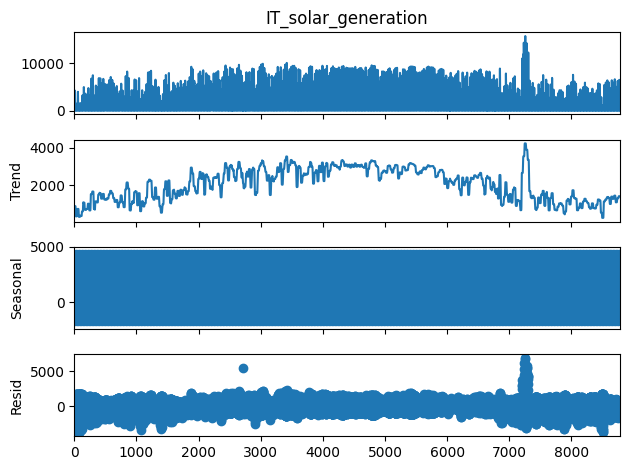

In [9]:
Raw_Solar_Seasonal = sd(df['IT_solar_generation'], period=24, model='Multiplicative')
Raw_Solar_Seasonal.plot();

In [10]:
# Adf Test On Log Load Data
solar_adf = adf(df['IT_solar_generation'], autolag='AIC')

Name = ['Statistic Value', 'P Value', 'Lag Used', 'Observation', 'Critical Values', 'AIC']

for name, test in zip(Name, solar_adf):
    print(f'{name} : {test}')

Statistic Value : -5.741334582271128
P Value : 6.265438259038684e-07
Lag Used : 36
Observation : 8747
Critical Values : {'1%': -3.43109782440793, '5%': -2.8618704886904087, '10%': -2.5669459141578455}
AIC : 123559.75076633792


# ARIMAM

## Load Arima Model

#### Visulize ACF and PACF

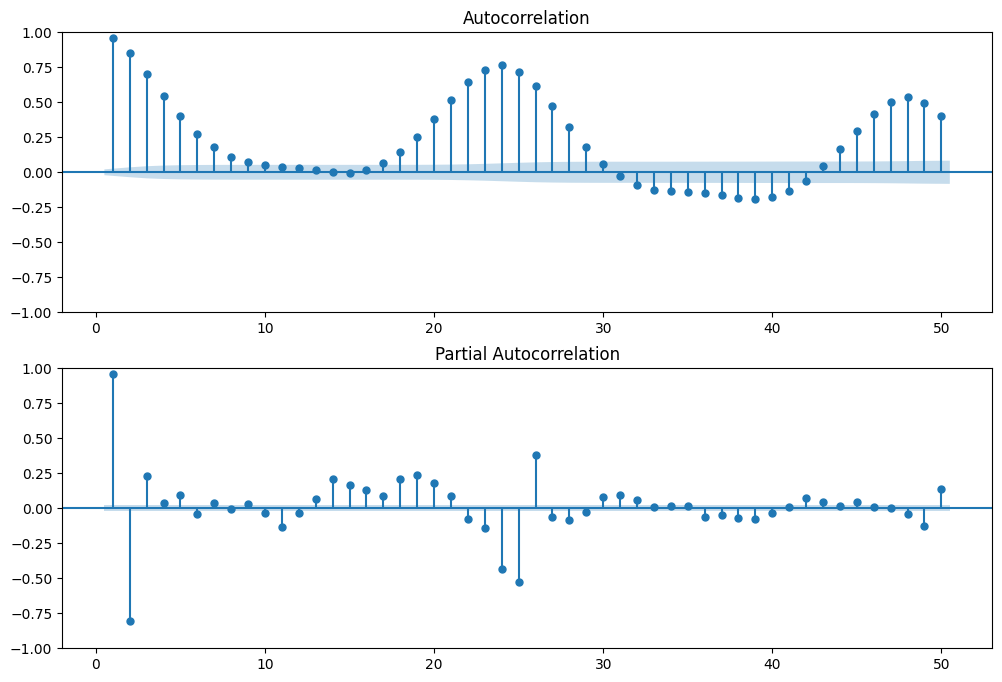

In [11]:
# For IT_load_new
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
acf(df['IT_load_new'], lags=50, zero=False, ax=axes[0]) #lags ==> max lag ≈ sqrt(N), N : Total Number of Observation
pacf(df['IT_load_new'], lags=50, zero=False, ax=axes[1])
plt.show()

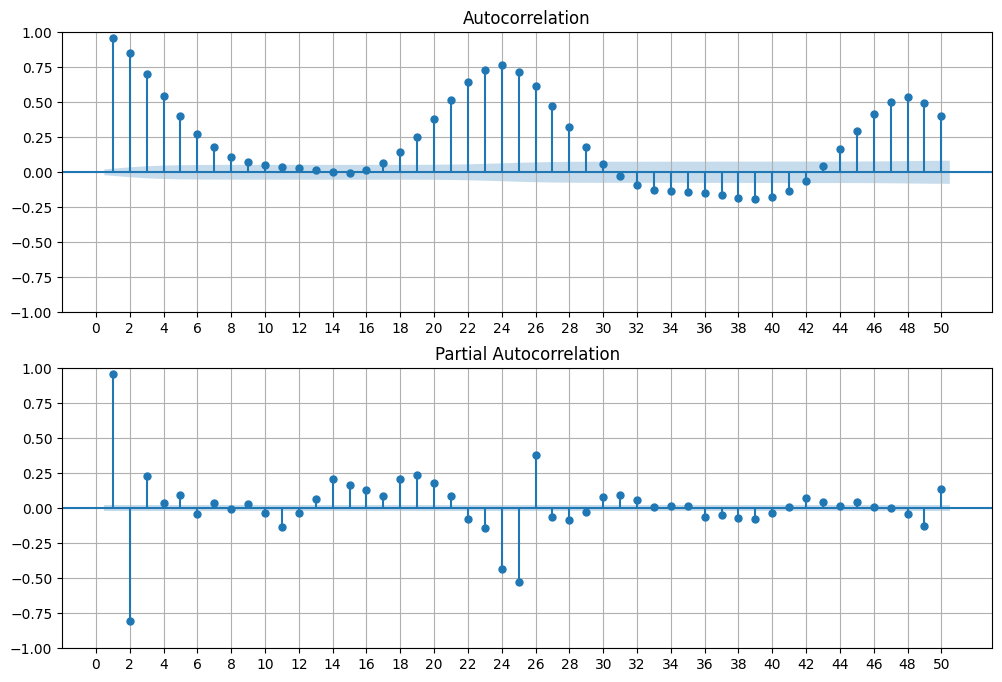

In [12]:
# For IT_load_new Same More Refine Version
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

acf(df['IT_load_new'], lags=50, zero=False, ax=axes[0])
axes[0].grid(True)
axes[0].set_xticks(np.arange(0, 51, 2))

pacf(df['IT_load_new'], lags=50, zero=False, ax=axes[1])
axes[1].grid(True)
axes[1].set_xticks(np.arange(0, 51, 2))

plt.show()

 By Visulization Technique PACF(p) : 1,2 ACF(q) : 1, 2, 8, 9, 10

In [12]:
# Create Hyper Parameter Grid Search Technique
p_values = [1, 2]
d_values = [0]
q_values = [1, 2, 8, 9, 10]


Values = []

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                order = (p, d, q)

                model = ARIMA(df['IT_load_new'], order=order)
                model_fit = model.fit()

                Values.append((model_fit.aic, order))

            except:
                continue

print('Best Values', sorted(Values)[0])

Best Values (148629.7791228879, (2, 0, 9))


In [3]:
# Auto Arima Model (Auto Hyper Perameter Optimization )
model = auto_arima(
    df['IT_load_new'],
    seasonal=False,
    stepwise=True,     # ⭐ speed optimization
    trace=True,
    suppress_warnings=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=150300.189, Time=1.18 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=207745.931, Time=0.10 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=195889.576, Time=1.75 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=151283.987, Time=2.38 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=150368.127, Time=2.80 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=5.84 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=150048.881, Time=6.17 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=150310.051, Time=3.43 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=149189.913, Time=9.69 sec
 ARIMA(4,0,3)(0,0,0)[0]             : AIC=149979.098, Time=12.49 sec
 ARIMA(3,0,4)(0,0,0)[0]             : AIC=149114.958, Time=8.67 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=inf, Time=10.05 sec
 ARIMA(4,0,4)(0,0,0)[0]             : AIC=149109.394, Time=10.25 sec
 ARIMA(5,0,4)(0,0,0)[0]

In [ ]:
# # Arima Best Order For Load(Walking Forward Method)
# # Train Test Split
# train_size = int(len(df['IT_load_new']) * 0.8)
# train = df['IT_load_new'][: train_size]
# test = df['IT_load_new'][train_size : ]


# history = [x for x in train]
# predictions = []

# for t in range(len(test)):
#     try:
#         model = ARIMA(history, order=(2, 0, 9))
#         model_fit = model.fit()
        
#         prediction = model_fit.forecast()[0]
#         predictions.append(prediction)
#         history.append(test[t])
#     except:
#         continue

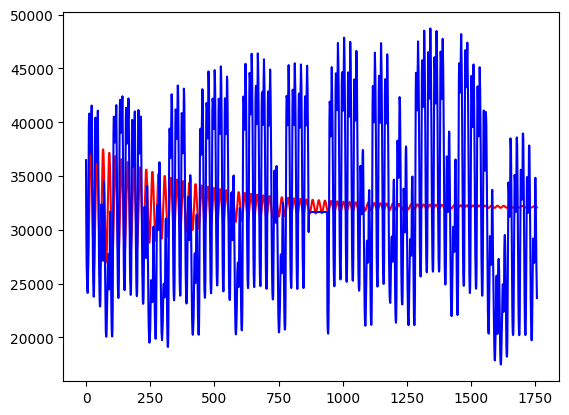

In [13]:
# ARIMA For Load
# Train Test Split
train_size = int(len(df['IT_load_new']) * 0.8)
train = df['IT_load_new'][: train_size]
test = df['IT_load_new'][train_size : ]


model = ARIMA(train, order=(2, 0, 9))
model_fit = model.fit()

predictions = model_fit.predict(start=len(train), end=len(train)+len(test)-1)

# Calculate RMSE
rmse = np.sqrt(mse(test, predictions))

# Visulization Foracaste
plt.plot(np.array(predictions), label='Prediction', color='Red')
plt.plot(test.values, label='Actual', color='Blue')
plt.show()

## Solar Arima Model

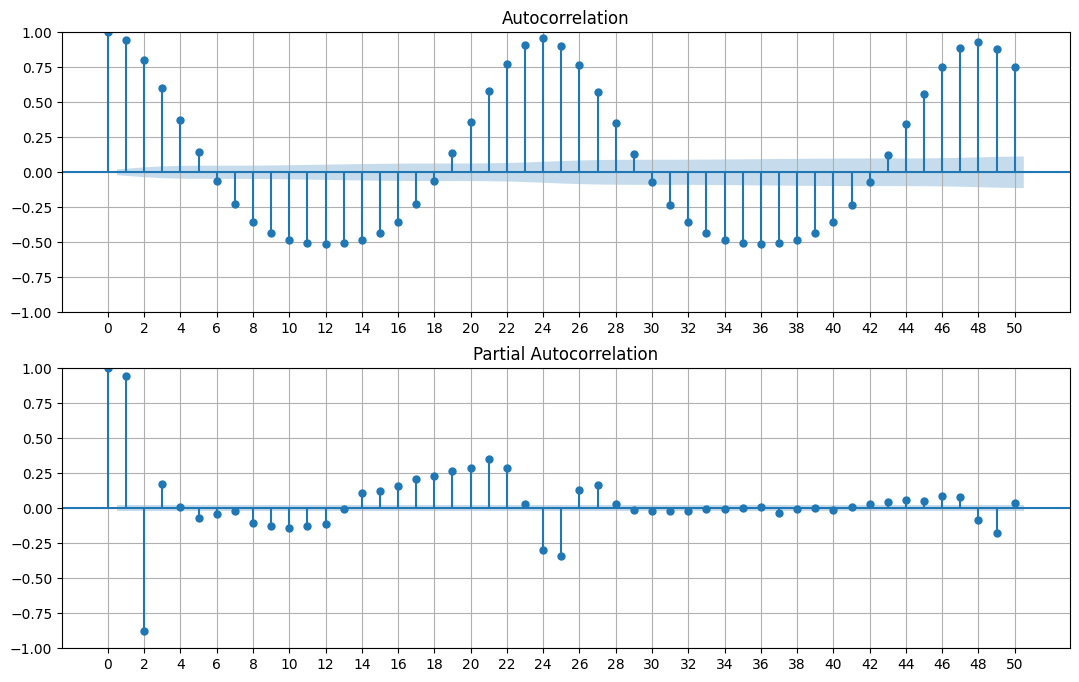

In [14]:
# Visulization PACF And ACF
fig, axes = plt.subplots(2,1, figsize=(13, 8))
acf(df['IT_solar_generation'], ax=axes[0], lags=50)
axes[0].set_xticks(np.arange(0, 51, 2))
axes[0].grid(True)

pacf(df['IT_solar_generation'], ax=axes[1], lags=50)
axes[1].set_xticks(np.arange(0, 51, 2))
axes[1].grid(True)

plt.show()

In [27]:
# Create Hyper Parameter Grid Search Technique
p_values = [0, 1, 2, 3]
q_values = [0, 1, 2, 5, 12]

values = []

for p in p_values:
    for q in q_values:
        try:
            order = (p, 0, q)
            model = ARIMA(df['IT_solar_generation'], order=order)
            model_fit = model.fit()
            result_aic = model_fit.aic
            values.append((result_aic, order))
            
        except:
            continue
    
print(f'Minimum AIC Order : {sorted(values)[0]}')

Minimum AIC Order : (131792.60916357604, (2, 0, 5))


RMSE : 432.6376996006385


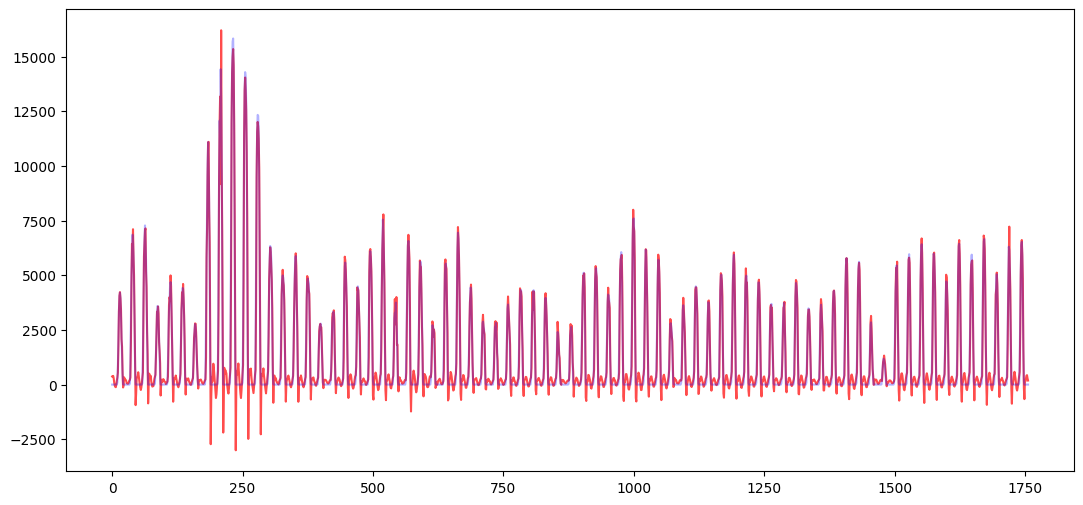

In [28]:
# Solar Generation Arima
# Train Test Split
train_size = int(len(df['IT_solar_generation']) * 0.8)
train = df['IT_solar_generation'][: train_size]
test = df['IT_solar_generation'][train_size : ]

IT_solar_generation = ARIMA(train, order=(2, 0, 5))
model_fit = model.fit()
prediction = model_fit.predict(start=len(train), end=len(train)+len(test)-1)

# RMSE 
print(f'RMSE : {np.sqrt(mse(test, prediction))}')

# Visulization
plt.figure(figsize=(13, 6))
plt.plot(np.array(prediction), color='Red', label='Predicted', alpha=0.7)
plt.plot(test.values, color='Blue', label='Actual', alpha=0.3)

plt.show()

Arima Is Failed

# SARIMA

## Solar Generation

In [ ]:
# SARIMA(p,d,q)(P,D,Q,m)
p_values = [0, 1, 2, 3]
q_values = [0, 1, 2, 5, 12]
P_values = [0, 1, 2]        # Seasonal AR
D_values = [0, 1]           # Seasonal Differencing
Q_values = [0, 1, 2]        # Seasonal MA
m        = 24               # Seasonal Period (24 hrs = 1 day)

values = []
for p, q, P, D, Q in product(p_values, q_values, P_values, D_values, Q_values):
    try:
        order         = (p, 0, q)
        seasonal_order = (P, D, Q, m)
        model         = SARIMAX(df['IT_solar_generation'],
                                order=order,
                                seasonal_order=seasonal_order)
        model_fit     = model.fit(disp=False)
        values.append((model_fit.aic, order, seasonal_order))
    except:
        continue

print(f'Minimum AIC Order : {sorted(values)[0]}')

In [ ]:
# Best SARIMA(2,0,5)(1,1,1,24) → AIC: 145678.32  ✅ BEST
# Train Test Split
train_size = int(len(df['IT_solar_generation'])*0.8)
train = df['IT_solar_generation'][:train_size]
test = df['IT_solar_generation'][train_size:]

# Model Initilization
model = SARIMAX(df['IT_solar_generation'], order=(2,0,5), seasonal_order=(1,1,1,24))
model_fit = model.fit()
print('AIC', model_fit.aic)
prediction = model_fit.predict(start=len(train), end=len(train)+len(test)-1)

# RMSE
RMSE_Score = np.sqrt(mae(test, prediction))
print('RMSE Score : \t', RMSE_Score)

In [ ]:
# Visulization 
plt.figure(figsize=(14, 9))
plt.plot(np.array(prediction), color='Blue', label='Prediction', alpha=0.2)
plt.plot(test.values, color='Black', label='Actual', alpha=0.5, linestyle='--')
plt.show()

In [ ]:
# Visulization 
fig, axes = plt.subplots(2, 1, figsize=(25, 12))
axes[0].plot(np.array(prediction), color='blue', label='Prediction')
axes[1].plot(test.values, color='black', label='Actual')
plt.show()

## Load

In [ ]:
# SARIMA(p,d,q)(P,D,Q,m)
p_values = [0, 1, 2, 3]
q_values = [0, 1, 2, 5, 12]
P_values = [0, 1, 2]        # Seasonal AR
D_values = [0, 1]           # Seasonal Differencing
Q_values = [0, 1, 2]        # Seasonal MA
m        = 24               # Seasonal Period (24 hrs = 1 day)

values = []

for p in p_values:
    for q in q_values:
        for P in P_values:
            for D in D_values:
                for Q in Q_values:

                    try:
                        order = (p,0,q)
                        Sarima_order = (P,D,Q, m)
                        model = SARIMAX(df['IT_new_load'], order=order, seasonal_order=Sarima_order)
                        model_fit = model.fit()
                        result = model_fit.aic
                        values.append((result, order, Sarima_order))
                    except:
                        continue

print('Best Results :\t', sorted(values)[0])
        
    

In [ ]:
# Meaning: best model is SARIMA(2,0,1)(1,1,1,24) with AIC = 1234.567
# Train Test Split 
train_size = int(len(df['IT_load_new'])*0.8)
train = df['IT_load_new'][:train_size]
test = df['IT_load_new'][train_size:]

# Model Initilize
model = SARIMAX(train, order=(2,0,1), seasonal_order=(1, 1, 1, 24))
model_fit = model.fit()
prediction = model_fit.predict(start=len(train), end=len(train)+len(test)-1)
aic_result = model_fit.aic

In [ ]:
# RMSE
print('RMSE Score : \t', np.sqrt(mse(test, prediction)))

In [ ]:
# Visulization
plt.figure(figsize=(85, 52))
plt.plot(test.values, color='red', label='Actual')
plt.plot(np.array(prediction), color='blue', label='Actual', alpha=0.4)
plt.legend(loc='best')
plt.grid()
plt.xticks(np.arange(0, 1750, 100))
plt.show()

In [ ]:
# Subplot Visulization
fig, axes = plt.subplots(2, 1, figsize=(15, 6))

axes[0].plot(test.values, color='red', label='Actual')
axes[0].set_xticks(np.arange(0, 1800, 100))
axes[0].grid(True)

axes[1].plot(np.array(prediction), color='blue', label='Actual', alpha=0.4)
axes[1].set_xticks(np.arange(0, 1800, 100))
axes[1].grid(True)